In [1]:
import json
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_metric_data(file, metric_name, prefix):
    with open(file) as f:
        data = json.load(f)
    
    metric_dict = data.get(metric_name, {})
    res = {}
    
    # 提取形如 'Acc/Eval/Exp1', 'Loss/Eval/Exp1' 的汇总指标
    for k, v in metric_dict.items():
        parts = k.split('/')
        if len(parts) == 3 and parts[0] == prefix and parts[1] == 'Eval' and parts[2].startswith('Exp'):
            try:
                exp_idx = int(parts[2].replace('Exp', '')) - 1
                res[exp_idx] = v
            except:
                continue
    
    # 排序并转为列表
    sorted_keys = sorted(res.keys())
    return [res[k] for k in sorted_keys]

找到 5 个结果文件: ['temp_model_cifar100_Lg2_Dg12_TRMreplace_VRMaccumulate_run1.json', 'temp_model_cifar100_Lg2_Dg12_TRMreplace_VRMaccumulate_run2.json', 'temp_model_cifar100_Lg2_Dg12_TRMreplace_VRMaccumulate_run3.json', 'temp_model_cifar100_Lg2_Dg12_TRMreplace_VRMaccumulate_run4.json', 'temp_model_cifar100_Lg2_Dg12_TRMreplace_VRMaccumulate_run5.json']


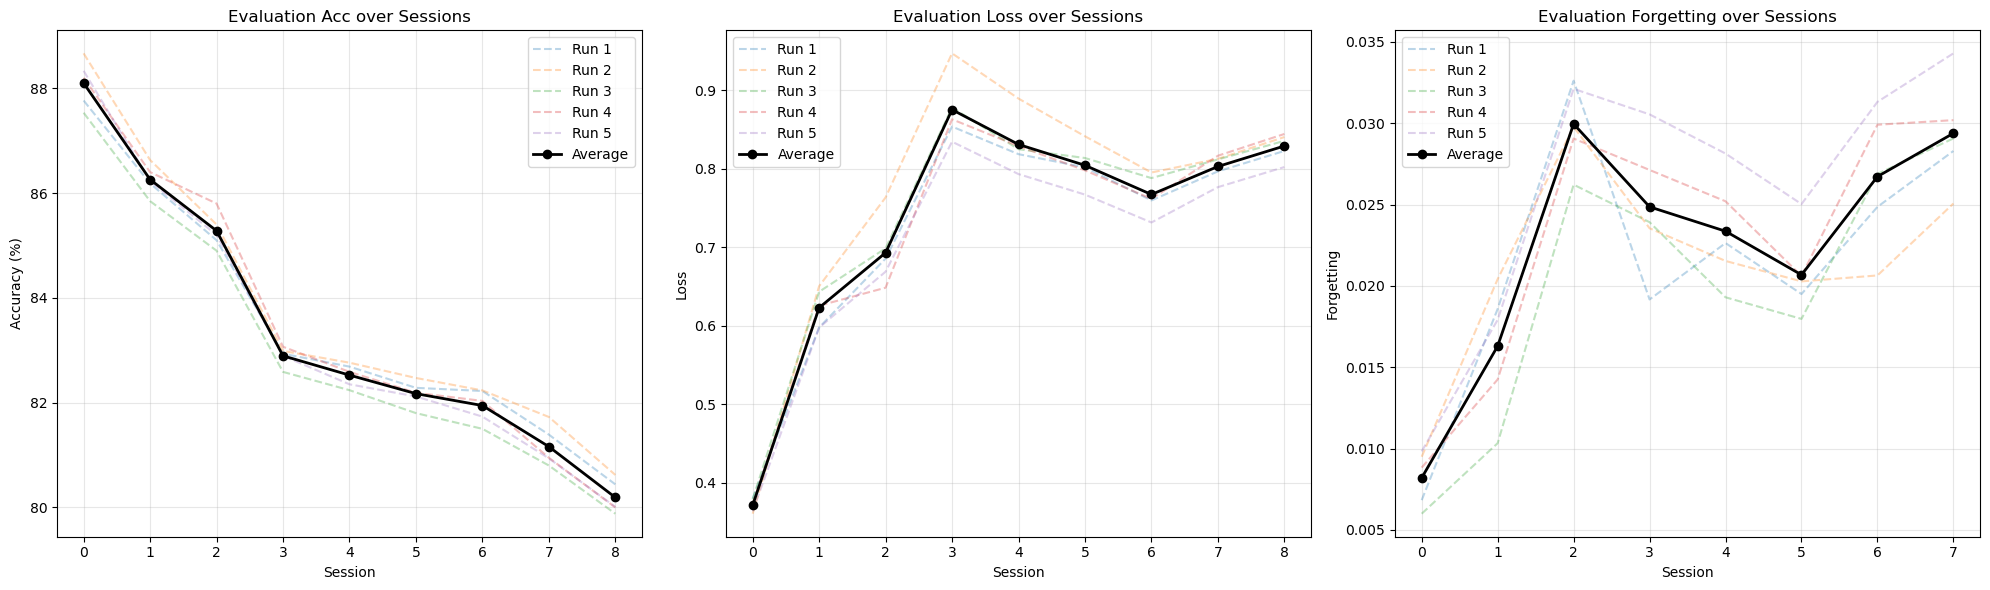

In [3]:
json_files = sorted(glob.glob('temp_model_*.json'))
print(f"找到 {len(json_files)} 个结果文件: {json_files}")

metrics_to_plot = [
    {'name': 'Acc', 'prefix': 'Acc', 'label': 'Accuracy (%)', 'scale': 100},
    {'name': 'Loss', 'prefix': 'Loss', 'label': 'Loss', 'scale': 1},
    {'name': 'Forgetting', 'prefix': 'Forgetting', 'label': 'Forgetting', 'scale': 1}
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, m in enumerate(metrics_to_plot):
    ax = axes[i]
    all_runs_data = []
    
    for f in json_files:
        run_data = get_metric_data(f, m['name'], m['prefix'])
        if not run_data: continue
        
        run_data = np.array(run_data) * m['scale']
        all_runs_data.append(run_data)
        
        run_id = f.split('_run')[-1].split('.')[0]
        ax.plot(run_data, linestyle='--', alpha=0.3, label=f"Run {run_id}")
    
    if all_runs_data:
        avg_data = np.mean(all_runs_data, axis=0)
        ax.plot(avg_data, marker='o', linewidth=2, color='black', label='Average')
        
    ax.set_title(f"Evaluation {m['name']} over Sessions")
    ax.set_xlabel("Session")
    ax.set_ylabel(m['label'])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()